# Benchmark: PXD014777 HeLa, Yeast and Ecoli dataset

We'll use PIPP to compute the embeddings of each MS datapoint. Followed by peptide identity propagation using the MS/MS data as the support data. Since multiple species are available in the MS/MS dataset, and only HeLA in the MS dataset, we'll also compute false discovery rates.

In [1]:
%%capture

%matplotlib inline
%load_ext autoreload
%autoreload 2

import pandas as pd
import umap
import matplotlib.pyplot as plt
import numpy as np

import pipp
import pipp.utils
import pickle

np.random.seed(0)

Let's define the paths to the data and the pretrained model.

In [2]:
PRETRAINED_MODEL_PATH = "../../checkpoints/checkpoint1.pth"

HELA_MS_OUT_PATH = "../../data/PXD014777/processed/hela_ms1.csv"
HELA_MSMS_OUT_PATH = "../../data/PXD014777/processed/hela_ms2.csv"
SPECIES_MSMS_OUT_PATH = "../../data/PXD014777/processed/species_ms2.csv"

In [3]:
df_ms_hela = pd.read_csv(HELA_MS_OUT_PATH, low_memory=False)
df_msms_hela = pd.read_csv(HELA_MSMS_OUT_PATH, low_memory=False)
df_msms_species = pd.read_csv(SPECIES_MSMS_OUT_PATH, low_memory=False)

## PIPP model

### Computing the Embeddings

Let's load the model and compute the embeddings.

In [4]:
model = pipp.Peptideprotonet.load(PRETRAINED_MODEL_PATH)

In [5]:
ms_hela_embeddings = model.compute_ms1_embeddings(df_ms_hela)
msms_hela_embeddings = model.compute_ms1_embeddings(df_msms_hela)
msms_species_embeddings = model.compute_ms1_embeddings(df_msms_species)

In [6]:
mean = ms_hela_embeddings.mean(axis=0)

ms_hela_embeddings -= mean
msms_hela_embeddings -= mean
msms_species_embeddings -= mean

#### Ecoli, Yeast and HeLa - MS/MS UMAP

Let's look at the embedding space.
We'll look at a subset of peptides due to memory limitations.

In [7]:
N = 50_000
random_indices = np.random.choice(range(len(df_msms_species)), size=N, replace=False)

Let's also add some "random" peptides to ensure all possible runs of at least a few peptides are included.

In [8]:
high_coverage_peptides_to_include = [
    "_(ac)AAAAAAAAAAGAAGGR_2",
    "_GLGAAEFGGAAGNVEAPGETFAQR_2",
    "_GLGLSPDLVVCR_2",
    "_SSLDNIEMAYAR_2",
    "_GLGHQVATDALVAMEK_3",
    "_SSMQIDNAPTPHNTPASVLNPSYLK_3",
    "_GLESLPPLRPQQNPVLPVAGER_3",
    "_GLELIASENFCSR_2",
    "_SSLAMIGHDGPNDMK_2",
]

low_coverage_peptides_to_include = [
    "_FTDEDEQGLR_2",
    "_SLPVPQLVPETEDEKK_2",
    "_EAEPDLLAVLR_2",
    "_SLPQTLILNPIR_2",
    "_DETGELSSADEK_2",
    "_GYLTDLNSMIPTHGGDINDIK_3",
    "_GYNPGLLVHPDLAYLQAEGGGDR_3",
    "_EVMQEVAQLSQFDEELYK_3",
    "_VPPATAFEGHMLLSGLEPFR_3",
    "_DEMLGLVPMR_2",
]

peptides_to_include = (
    high_coverage_peptides_to_include + low_coverage_peptides_to_include
)

custom_indices = [
    df_msms_species.index[df_msms_species["PrecursorID"] == peptide].tolist()
    for peptide in peptides_to_include
]
custom_indices = [
    peptide for peptide_runs in custom_indices for peptide in peptide_runs
]
custom_indices = [df_msms_species.index.get_loc(i) for i in custom_indices]

In [9]:
indices = np.unique(np.concatenate((random_indices, custom_indices)))

In [10]:
df_msms_subset = df_msms_species.iloc[indices]
msms_subset_embeddings = msms_species_embeddings[indices]

Let's compute the UMAP for plotting.

In [11]:
reducer = umap.UMAP(metric="cosine")
umap_embedding = reducer.fit_transform(msms_subset_embeddings)

(0.0, 1.0, 0.0, 1.0)

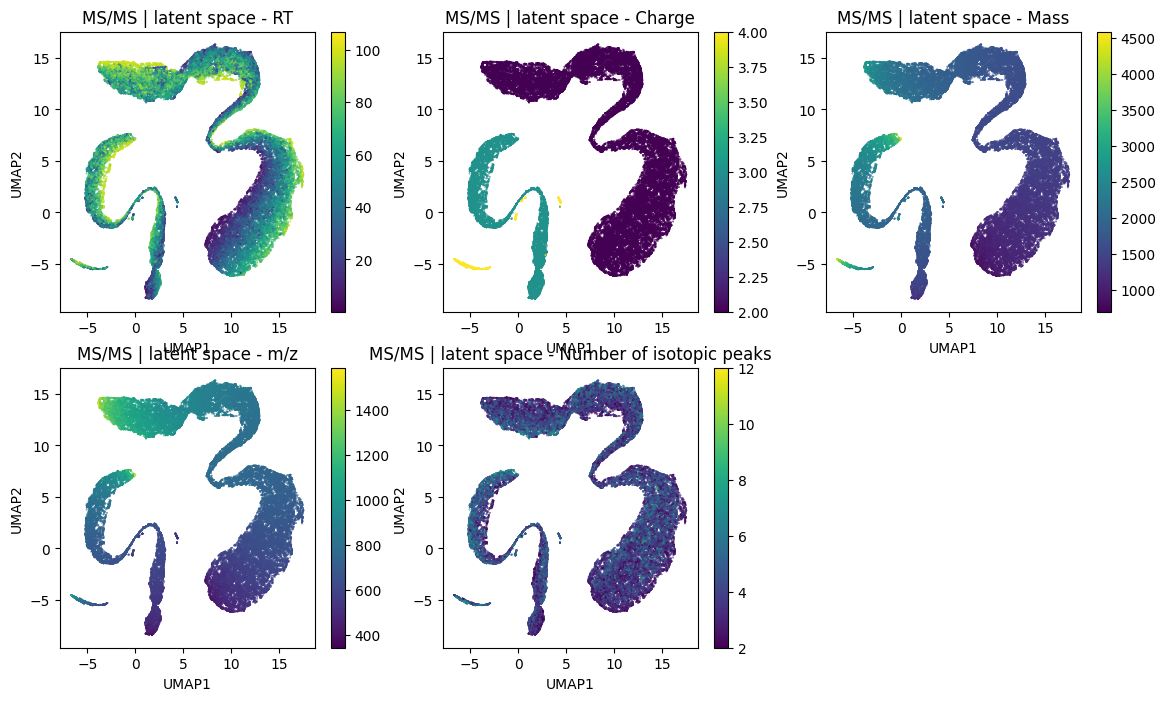

In [12]:
fig, axs = plt.subplots(figsize=(14, 8), ncols=3, nrows=2)

ax = axs[0][0]
sp = ax.scatter(
    umap_embedding[:, 0],
    umap_embedding[:, 1],
    c=df_msms_subset["Retention time"],
    s=0.1,
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("MS/MS | latent space - RT")
fig.colorbar(sp)

ax = axs[0][1]
sp = ax.scatter(
    umap_embedding[:, 0], umap_embedding[:, 1], c=df_msms_subset["Charge"], s=0.1
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("MS/MS | latent space - Charge")
fig.colorbar(sp)

ax = axs[0][2]
sp = ax.scatter(
    umap_embedding[:, 0], umap_embedding[:, 1], c=df_msms_subset["Mass"], s=0.1
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("MS/MS | latent space - Mass")
fig.colorbar(sp)

ax = axs[1][0]
sp = ax.scatter(
    umap_embedding[:, 0], umap_embedding[:, 1], c=df_msms_subset["m/z"], s=0.1
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("MS/MS | latent space - m/z")
fig.colorbar(sp)

ax = axs[1][1]
sp = ax.scatter(
    umap_embedding[:, 0],
    umap_embedding[:, 1],
    c=df_msms_subset["Number of isotopic peaks"],
    s=0.1,
)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("MS/MS | latent space - Number of isotopic peaks")
fig.colorbar(sp)

ax = axs[1][2]
ax.axis("off")

Let's plot the latent space for each specie. We'll scale based on proportion of peptides in each specie.

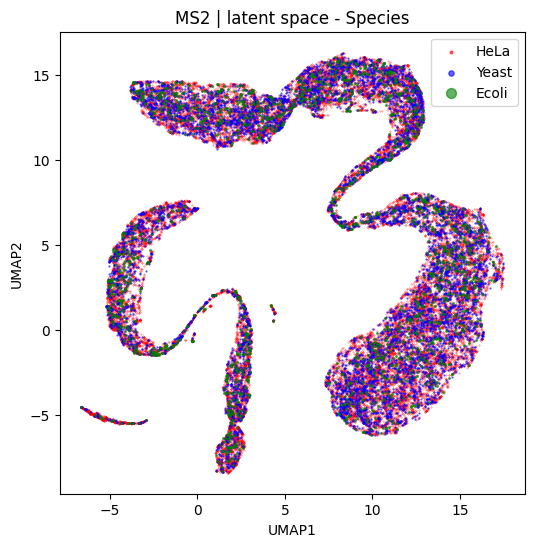

In [13]:
colors = ["red", "blue", "green"]
color_map = {
    species: color for species, color in zip(df_msms_subset["Species"].unique(), colors)
}
species_size = {"HeLa": 0.1, "Yeast": 0.4, "Ecoli": 1.4}

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("MS2 | latent space - Species")

for species, color in color_map.items():
    umap1 = umap_embedding[df_msms_subset["Species"] == species][:, 0]
    umap2 = umap_embedding[df_msms_subset["Species"] == species][:, 1]
    ax.scatter(umap1, umap2, c=color, s=species_size[species], label=species, alpha=0.6)

ax.legend(markerscale=6)

Let's also plot the latent space of the MS/MS data together with some low coverage and high coverage peptides.

Text(0.5, 1.0, 'low coverage peptides')

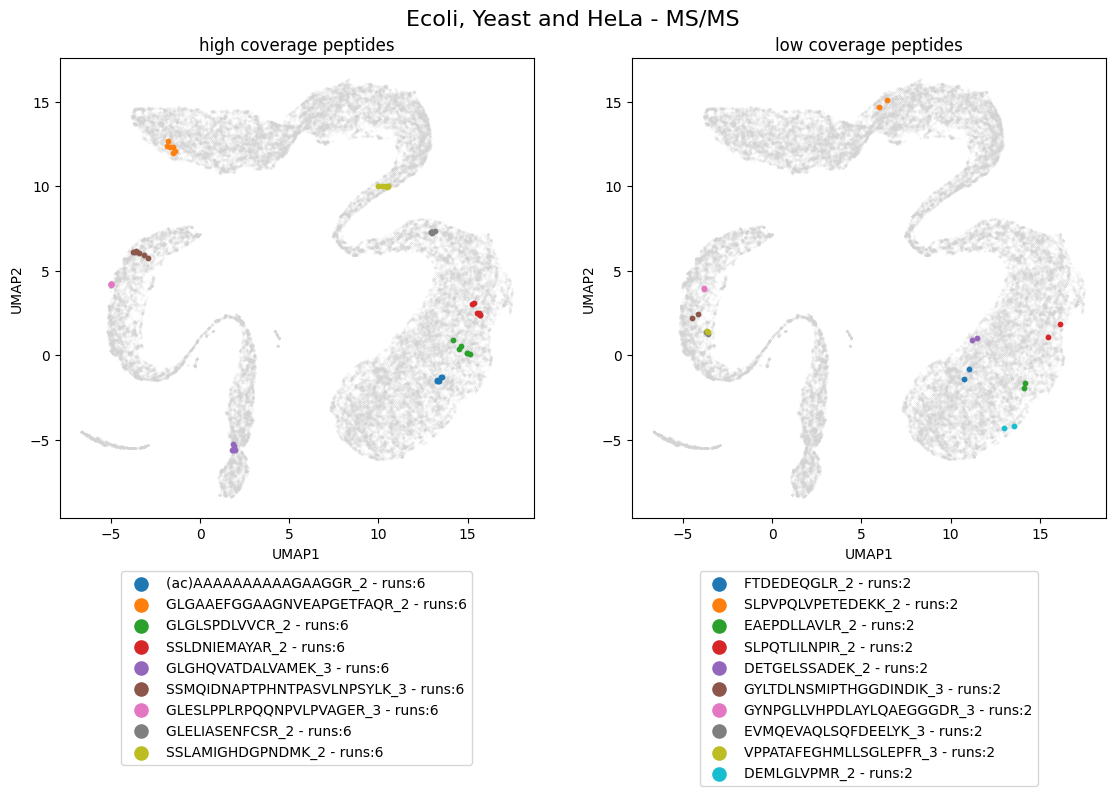

In [14]:
peptide_abundances = df_msms_species["PrecursorID"].value_counts()

fig, axs = plt.subplots(figsize=(12, 6), ncols=2, nrows=1)
fig.tight_layout(pad=4.0)

fig.suptitle("Ecoli, Yeast and HeLa - MS/MS", fontsize=16)

# high coverage peptides
ax = axs[0]
ax.scatter(umap_embedding[:, 0], umap_embedding[:, 1], s=0.01, color="lightgrey")

for i, peptide in enumerate(high_coverage_peptides_to_include):
    peptide_ref_indices = np.where(df_msms_subset["PrecursorID"] == peptide)
    ax.scatter(
        umap_embedding[peptide_ref_indices, 0],
        umap_embedding[peptide_ref_indices, 1],
        s=10,
        color=plt.cm.tab10(i),
        label=f"{peptide[1:]} - runs:{peptide_abundances[peptide]}",
    )

ax.legend(markerscale=3, loc="upper center", bbox_to_anchor=(0.5, -0.1))
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("high coverage peptides")

# low coverage peptides
ax = axs[1]
ax.scatter(umap_embedding[:, 0], umap_embedding[:, 1], s=0.01, color="lightgrey")

for i, peptide in enumerate(low_coverage_peptides_to_include):
    peptide_ref_indices = np.where(df_msms_subset["PrecursorID"] == peptide)
    ax.scatter(
        umap_embedding[peptide_ref_indices, 0],
        umap_embedding[peptide_ref_indices, 1],
        s=10,
        color=plt.cm.tab10(i),
        label=f"{peptide[1:]} - runs:{peptide_abundances[peptide]}",
    )

ax.legend(markerscale=3, loc="upper center", bbox_to_anchor=(0.5, -0.1))
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("low coverage peptides")

Let's also plot the latent representation of both MS2 datasets.

In [15]:
df_msms_all = pd.concat([df_msms_hela, df_msms_species], ignore_index=True)

In [16]:
msms_embeddings = model.compute_ms1_embeddings(df_msms_all)

In [17]:
print(f"Number of prototypes: {df_msms_all['PrecursorID'].nunique()}")

Number of prototypes: 86678


In [18]:
N = 50_000
M = N // 2

hela_random_indices = np.random.choice(range(len(df_msms_hela)), size=M, replace=False)
species_random_indices = np.random.choice(
    range(len(df_msms_species)), size=M, replace=False
)

random_indices = np.concatenate(
    (hela_random_indices, species_random_indices + len(df_msms_hela))
)

msms_subset_embeddings = msms_embeddings[random_indices]
df_msms_subset = df_msms_all.iloc[random_indices]

In [19]:
reducer = umap.UMAP(metric="cosine")
umap_embedding = reducer.fit_transform(msms_subset_embeddings)

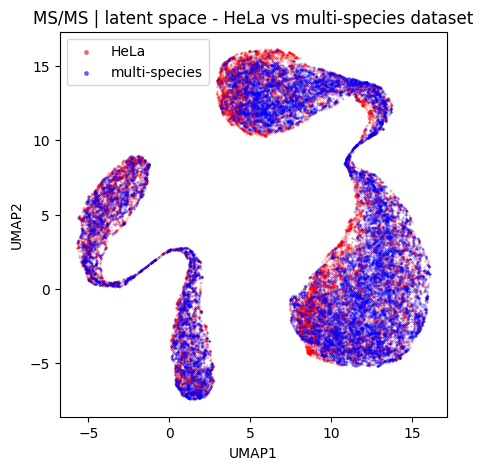

In [20]:
colors = ["red", "blue"]
color_map = {
    dataset: color for dataset, color in zip(df_msms_all["dataset"].unique(), colors)
}

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("MS/MS | latent space - HeLa vs multi-species dataset")

for dataset, color in color_map.items():
    umap1 = umap_embedding[df_msms_subset["dataset"] == dataset][:, 0]
    umap2 = umap_embedding[df_msms_subset["dataset"] == dataset][:, 1]
    ax.scatter(umap1, umap2, c=color, s=0.1, label=dataset, alpha=0.5)

ax.legend(markerscale=8)

## Peptide Identity Propagation

Let's first extract the HeLa MS2 entries from the HeLa MS data.

In [21]:
df_ms_hela.set_index("id", inplace=True, drop=False)
df_msms_hela.set_index("id", inplace=True, drop=False)

ms_only_locs = df_ms_hela.index.difference(df_msms_hela.index)
df_ms_query = df_ms_hela.loc[ms_only_locs]

Let's append the species to the precursors.

In [22]:
species_precursor_id = df_msms_all["Species"].str.cat(
    df_msms_all["PrecursorID"].astype(str), sep=""
)
df_msms_all["PrecursorID"] = species_precursor_id

### Optional: Preparing MSMS sequence embeddings


See `hela_yeat_ecoli_multi_analysis.ipynb` for more info on how to generate MSMS sequence embeddings.

Assuming the embeddings are already generated, let's load them. Change the path to the embeddings file if needed. Afterwards, define the number of PCA components to use for the embeddings.


In [23]:
PATH = "../../data/PXD014777/embeddings/prototype_embeddings.pkl"
N_PCS = 5

try:
    with open(PATH, "rb") as f:
        prototype_embeddings = pickle.load(f)

    ms2_embeddings = pipp.utils.pca(prototype_embeddings, n_pcs=N_PCS)
except FileNotFoundError:
    print("MSMS sequence embedding file not found!")
    ms2_embeddings = None

MSMS sequence embedding file not found!


### Identification on the MS data

In [24]:
k_neighbours = 15
n_anchor = 5
n_pc = 5

In [25]:
identifications, confidence = model.propagate(
    df_ms_query,
    df_msms_all,
    k_neighbours=k_neighbours,
    n_anchors=n_anchor,
)

In [26]:
df_ms_query["pred_ident"] = identifications
df_ms_query["pred_confidence"] = confidence
df_ms_query["pred_species"] = df_ms_query["pred_ident"].str.split("_").str[0]

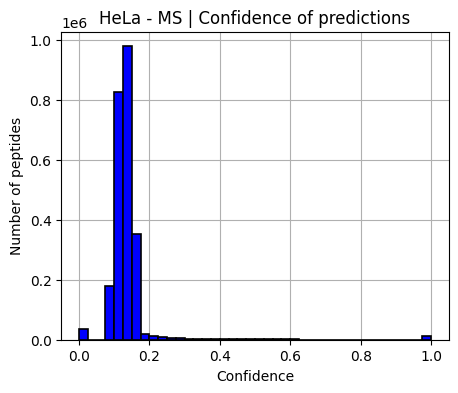

In [27]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(
    df_ms_query["pred_confidence"],
    bins=40,
    color="blue",
    edgecolor="black",
    linewidth=1.2,
)
ax.set_title("HeLa - MS | Confidence of predictions")
ax.set_xlabel("Confidence")
ax.set_ylabel("Number of peptides")
ax.grid(True)
ax.set_axisbelow(True)

In [28]:
N = 25_000

ms_hela_random_indices = np.random.choice(
    range(df_ms_query.shape[0]), size=N, replace=False
)

df_ms_hela_random_subset = df_ms_query.iloc[ms_hela_random_indices]
ms_subset_embeddings = model.compute_ms1_embeddings(df_ms_hela_random_subset)

reducer = umap.UMAP(metric="cosine")
umap_embedding = reducer.fit_transform(ms_subset_embeddings)

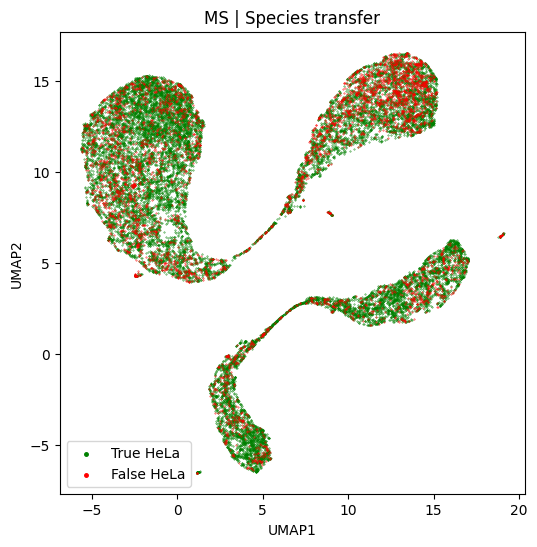

In [29]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("MS | Species transfer")

hela_mask = df_ms_hela_random_subset["pred_species"] == "HeLa"
ax.scatter(
    umap_embedding[hela_mask, 0],
    umap_embedding[hela_mask, 1],
    c="green",
    s=0.1,
    label="True HeLa",
)

non_hela_mask = ~hela_mask
ax.scatter(
    umap_embedding[non_hela_mask, 0],
    umap_embedding[non_hela_mask, 1],
    c="red",
    s=0.1,
    label="False HeLa",
)

ax.legend(markerscale=8)

In [30]:
def prepare_for_fdr(df_ms: pd.DataFrame) -> pd.DataFrame:
    pos_identifications = df_ms["pred_species"] == "HeLa"
    neg_identifications = ~pos_identifications
    run = df_ms["Raw file"]

    return pd.DataFrame(
        {
            "run": run,
            "pos": pos_identifications,
            "neg": neg_identifications,
        }
    )

In [31]:
prototypes = model.get_prototype_sequences(df_msms_all)

In [32]:
prototype_species = [precursor.split("_")[0] for precursor in prototypes]
n_pos_prototypes = sum([species == "HeLa" for species in prototype_species])
n_species_prototypes = sum([species != "HeLa" for species in prototype_species])

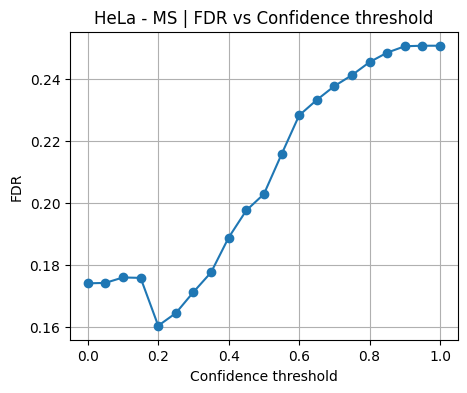

In [33]:
confidence_thresholds = np.linspace(0, 1, 21)

results = []
for threshold in confidence_thresholds:
    df_ms_query_subset = df_ms_query[df_ms_query["pred_confidence"] >= threshold]
    fdr = pipp.utils.compute_pipp_fdr(prepare_for_fdr(df_ms_query_subset))
    results += [(threshold, fdr)]

results = pd.DataFrame(results, columns=["threshold", "FDR"])

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(results["threshold"], results["FDR"], marker="o")
ax.set_title("HeLa - MS | FDR vs Confidence threshold")
ax.set_xlabel("Confidence threshold")
ax.set_ylabel("FDR")
ax.grid(True)